*Analyzing data structure*

In [1]:
pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]
Note: you may need to restart the kernel to use updated packages.


In [45]:
import pandas as pd
import numpy as np

df = pd.read_excel("Online_Retail.xlsx")


In [5]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [7]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


Take aways from analyzing the data:
- Invoice Date is already in datetime
- Need to remove null customer ID values 
- Need to investigate why there is negative unit prices 
- Since Invoice No did not come in the stats meant there were alpha objects(research and saw these were cancellations)

Data cleaning 

In [46]:
# Remove values missing customer data 
df_nonull = df[df["CustomerID"].notna()]
df_nonull.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.9+ MB


In [47]:
# Remove cancelled orders
df_nocancel = df_nonull[~df_nonull['InvoiceNo'].astype(str).str.startswith('C')]
df_nocancel.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397924 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397924 non-null  object        
 1   StockCode    397924 non-null  object        
 2   Description  397924 non-null  object        
 3   Quantity     397924 non-null  int64         
 4   InvoiceDate  397924 non-null  datetime64[ns]
 5   UnitPrice    397924 non-null  float64       
 6   CustomerID   397924 non-null  float64       
 7   Country      397924 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.3+ MB


Negative quantities and unit prices are due to returns made by customers. Best practice looking at my research question would be to remove these values. This is as I am trying to model consumer purchasing patterns and not customer satisfaction or product quality. While these aspects may have possible mediator effects they would potentialy obcure results.

In [48]:
df_final= df_nocancel[(df_nocancel['Quantity'] > 0) & (df_nocancel['UnitPrice'] > 0)]

df_final.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,397884.000000,397884,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023360,3.116488,15294.423453
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,179.331775,NaN,22.097877,1713.141560


Feature Engineering:
1. Recency (days since purchase)
2. Frequency (how often does a customer purchase)
3. Monetary value (how much has each customer bought in ttl)
4. Average order value (for each customer)
5. Number of unique products purchased (per customer)


In [49]:
# Creating the recency feature 

last_order_date = df_final["InvoiceDate"].max()

# Finds the most recent order for each customer 
customer_recent_order = df_final.groupby("CustomerID")["InvoiceDate"].max()

# Compares purchase to most recent order date 
customer_recency = last_order_date - customer_recent_order

# Use dt.days to be able to access the days in the timedelta dtype 
customer_recency_days = customer_recency.dt.days

customer_recency_days



CustomerID
12346.0    325
12347.0      1
12348.0     74
12349.0     18
12350.0    309
          ... 
18280.0    277
18281.0    180
18282.0      7
18283.0      3
18287.0     42
Name: InvoiceDate, Length: 4338, dtype: int64

In [50]:
# Frequency 
frequency_counts = df_final.groupby("CustomerID").size()
frequency_counts

CustomerID
12346.0      1
12347.0    182
12348.0     31
12349.0     73
12350.0     17
          ... 
18280.0     10
18281.0      7
18282.0     12
18283.0    756
18287.0     70
Length: 4338, dtype: int64

In [51]:
# Monetary value 

# Need to create a total price column 
df_final["TotalOrderPrice"] = df_final["Quantity"] * df_final["UnitPrice"]

df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   InvoiceNo        397884 non-null  object        
 1   StockCode        397884 non-null  object        
 2   Description      397884 non-null  object        
 3   Quantity         397884 non-null  int64         
 4   InvoiceDate      397884 non-null  datetime64[ns]
 5   UnitPrice        397884 non-null  float64       
 6   CustomerID       397884 non-null  float64       
 7   Country          397884 non-null  object        
 8   TotalOrderPrice  397884 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB


/var/folders/dp/cpk_3bwd6_380gkggyzz55g40000gn/T/ipykernel_90600/1643019352.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final["TotalOrderPrice"] = df_final["Quantity"] * df_final["UnitPrice"]


In [52]:
# Monetary value per customer 
monetary_value= df_final.groupby("CustomerID")["TotalOrderPrice"].sum()

monetary_value

CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
             ...   
18280.0      180.60
18281.0       80.82
18282.0      178.05
18283.0     2094.88
18287.0     1837.28
Name: TotalOrderPrice, Length: 4338, dtype: float64

In [53]:
# Average order value 
avg_order_value = df_final.groupby("CustomerID")["TotalOrderPrice"].mean()

avg_order_value


CustomerID
12346.0    77183.600000
12347.0       23.681319
12348.0       57.975484
12349.0       24.076027
12350.0       19.670588
               ...     
18280.0       18.060000
18281.0       11.545714
18282.0       14.837500
18283.0        2.771005
18287.0       26.246857
Name: TotalOrderPrice, Length: 4338, dtype: float64

In [54]:
# Number of unique items 
unique_items = df_final.groupby("CustomerID")["StockCode"].nunique()

unique_items

CustomerID
12346.0      1
12347.0    103
12348.0     22
12349.0     73
12350.0     17
          ... 
18280.0     10
18281.0      7
18282.0     12
18283.0    263
18287.0     59
Name: StockCode, Length: 4338, dtype: int64

In [55]:
# Combining into one feauture engineered table 
df_features = pd.DataFrame({"Recency": customer_recency_days, 
                            "Frequency": frequency_counts,
                            "MonetaryValue": monetary_value,
                            "AverageOrderValue": avg_order_value,
                            "UniqueItems": unique_items})



df_features

,Recency,Frequency,MonetaryValue,AverageOrderValue,UniqueItems
CustomerID,,,,,
12346.0,325,1,77183.60,77183.600000,1
12347.0,1,182,4310.00,23.681319,103
12348.0,74,31,1797.24,57.975484,22
12349.0,18,73,1757.55,24.076027,73
12350.0,309,17,334.40,19.670588,17
...,...,...,...,...,...
18280.0,277,10,180.60,18.060000,10
18281.0,180,7,80.82,11.545714,7
18282.0,7,12,178.05,14.837500,12


Overall feature engennering was not too difficult or time consuming the only concept that was new was the timedelta datatype 

Next to be able to continue modelling I need to scale my data. K-means is based on eucliean distance hence any value with money will dominate the variablilty and hence I want to normalize all the data values.

NORMALIZATION/STANDARDIZATION OF FEATURES

I picked standardization as I wanted the data to be less sensitive to outliers and I thought having the data be normally distrubuted might help my interpretations of clustering results 

In [56]:
import sklearn 
from sklearn import preprocessing

scaler = preprocessing.StandardScaler().fit(df_features)

features_scaled = scaler.transform(df_features)
features_scaled


array([[ 2.33457414e+00, -3.96577702e-01,  8.35866818e+00,
         5.25397824e+01, -7.08801901e-01],
       [-9.05340320e-01,  3.94648958e-01,  2.50966264e-01,
        -3.04337907e-02,  4.86180191e-01],
       [-1.75359593e-01, -2.65435162e-01, -2.85960063e-02,
        -7.06865876e-03, -4.62776177e-01],
       ...,
       [-8.45341904e-01, -3.48492104e-01, -2.08742313e-01,
        -3.64592177e-02, -5.79931284e-01],
       [-8.85340848e-01,  2.90384290e+00,  4.51854273e-03,
        -4.46803025e-02,  2.36066191e+00],
       [-4.95351144e-01, -9.49498596e-02, -2.41412739e-02,
        -2.86858506e-02, -2.93022801e-02]])

In [57]:
# Output is in array and lost column names 
# Need to convert it back to df

df_scaled = pd.DataFrame(features_scaled, 
                         columns=df_features.columns, 
                         index=df_features.index)

df_scaled.head()

,Recency,Frequency,MonetaryValue,AverageOrderValue,UniqueItems
CustomerID,,,,,
12346.0,2.334574,-0.396578,8.358668,52.539782,-0.708802
12347.0,-0.905340,0.394649,0.250966,-0.030434,0.486180
12348.0,-0.175360,-0.265435,-0.028596,-0.007069,-0.462776
12349.0,-0.735345,-0.081836,-0.033012,-0.030165,0.134715
12350.0,2.174578,-0.326635,-0.191347,-0.033166,-0.521354


In [40]:
# Inspect scaled feature tablle 
df_scaled.describe()


,Recency,Frequency,MonetaryValue,AverageOrderValue,UniqueItems
count,4.338000e+03,4.338000e+03,4.338000e+03,4.338000e+03,4.338000e+03
mean,2.702618e-17,1.801745e-17,1.801745e-17,-7.370775e-18,-1.801745e-17
std,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00
min,-9.153401e-01,-3.965777e-01,-2.281344e-01,-4.513659e-02,-7.088019e-01
25%,-7.453445e-01,-3.266350e-01,-1.943495e-01,-3.814352e-02,-5.330692e-01
50%,-4.153533e-01,-2.217210e-01,-1.535104e-01,-3.449320e-02,-3.104745e-01
75%,4.946227e-01,3.619268e-02,-4.367134e-02,-2.963182e-02,1.815769e-01
max,2.814561e+00,3.390157e+01,3.094634e+01,5.253978e+01,2.021510e+01


Modelling 

Text(0, 0.5, 'Inertia')

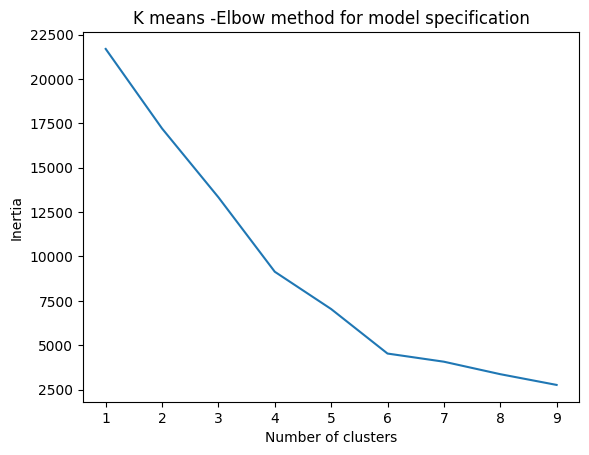

In [60]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


costs = []
k_values = range(1, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init="auto")
    kmeans.fit(df_scaled)
    costs.append(kmeans.inertia_)
    
plt.plot(k_values, costs)
plt.title("K means -Elbow method for model specification")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
    



Looking at the elbow plot I would pick 6 clusters as the drop in distance between the points and clusters is making significantly smaller drops after the 6 cluster assigment and I need to to pick a smaller cluster number to be able to interpret them.

In [62]:
# Running k-means

kmeans = KMeans(n_clusters=6, random_state=0, n_init="auto").fit(df_scaled)
df_scaled["Cluster"] = kmeans.labels_

df_scaled.head()


,Recency,Frequency,MonetaryValue,AverageOrderValue,UniqueItems,Cluster
CustomerID,,,,,,
12346.0,2.334574,-0.396578,8.358668,52.539782,-0.708802,1
12347.0,-0.905340,0.394649,0.250966,-0.030434,0.486180,2
12348.0,-0.175360,-0.265435,-0.028596,-0.007069,-0.462776,2
12349.0,-0.735345,-0.081836,-0.033012,-0.030165,0.134715,2
12350.0,2.174578,-0.326635,-0.191347,-0.033166,-0.521354,0


Next I need to intepret the clusters in order to achieve customer segmentation. 

In [63]:
df_scaled.groupby("Cluster").mean()

,Recency,Frequency,MonetaryValue,AverageOrderValue,UniqueItems
Cluster,,,,,
0,1.570391,-0.284501,-0.166870,-0.009631,-0.438256
1,0.709617,-0.392206,13.436935,45.377083,-0.697086
2,-0.472135,-0.127139,-0.075051,-0.023757,-0.151852
3,-0.905340,24.983875,7.662387,-0.037940,16.843962
4,-0.835342,3.933749,21.504585,0.167845,4.274976
5,-0.722779,1.318796,0.545956,-0.032312,1.958505


In [70]:
cluster_0 = ["high", "low", "low", "low", "low"]
cluster_1 = ["med", "low", "high", "vhigh", "low"]
cluster_2 = ["low", "low", "low", "low", "low"]
cluster_3 = ["low", "vhigh", "high", "low", "vhigh"]
cluster_4 = ["low", "high", "vhigh", "low", "high"]
cluster_5 = ["low", "med", "low", "low", "med"]

index_values = [0, 1, 2, 3, 4, 5]
index = pd.Index(index_values, name= "Clusters")
col_names = ["Recency", "Frequency", "MonetaryValue", "AverageOrderValue", "UniqueItems"]

cluster_metrics = pd.DataFrame([cluster_0, 
                                cluster_1, 
                                cluster_2, 
                                cluster_3, 
                                cluster_4, 
                                cluster_5],
                              columns=col_names,
                              index=index)

cluster_metrics

,Recency,Frequency,MonetaryValue,AverageOrderValue,UniqueItems
Clusters,,,,,
0,high,low,low,low,low
1,med,low,high,vhigh,low
2,low,low,low,low,low
3,low,vhigh,high,low,vhigh
4,low,high,vhigh,low,high
5,low,med,low,low,med
